# A simple 2D Flow Matching model

This notebook trains and evaluates a simple 2D FM model with CondOT (i.e., linear) scheduler.

Dataset: 2D checkerboard
Model (velocity): MLP

## Imports and init device

In [1]:
import time
import torch

from torch import nn, Tensor

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

# visualization
import matplotlib.pyplot as plt

from matplotlib import cm


# To avoide meshgrid warning
import warnings

from sklearn.datasets import make_moons
import numpy as np
from scipy.stats import vonmises as scipy_vonmises
from scipy.stats import lognorm as scipy_lognorm

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


In [3]:
torch.manual_seed(42)

## Dataset

In [4]:
def inf_train_gen(batch_size: int = 200, device: str = "cpu"):
    x1 = torch.rand(batch_size, device=device) * 4 - 2
    x2_ = torch.rand(batch_size, device=device) - torch.randint(high=2, size=(batch_size, ), device=device) * 2
    x2 = x2_ + (torch.floor(x1) % 2)

    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45
    
    return data.float()

In [5]:
def two_moons_data(batch_size: int = 200, device: str = "cpu"):
    x, _ = make_moons(n_samples=batch_size, noise=0.1, random_state=42)
    data = torch.tensor(x, device=device).float()
    return data

In [6]:
def two_moons_data_with_cond(batch_size: int = 200, device: str = "cpu"):
    x, y = make_moons(n_samples=batch_size, noise=0.1, random_state=42)
    data = torch.tensor(x, device=device).float()
    cond = torch.tensor(y, device=device).float()
    
    total_data = torch.cat([data, cond[:, None]], dim=1)
    return total_data

In [7]:
def multi_blob_data_with_cond(batch_size: int = 200, n_classes: int = 4, noise: float = 0.4, device: str = "cpu"):
    """
    Generates a toy dataset with multiple blobs, where each blob is a class.
    """
    # Define the centers for the blobs
    angles = torch.linspace(0, 2 * torch.pi, n_classes + 1, device=device)[:-1]
    radius = 2.5
    centers = torch.stack([radius * torch.cos(angles), radius * torch.sin(angles)], dim=1)
    
    # Assign each point in the batch to a random class
    y = torch.randint(0, n_classes, (batch_size,), device=device)
    
    # Create the data points by selecting the center and adding noise
    x = centers[y] + torch.randn(batch_size, 2, device=device) * noise
    
    data = x.float()
    cond = y.float()
    
    total_data = torch.cat([data, cond[:, None]], dim=1)
    return total_data

In [8]:
def semicircle_data():
    """
    Loads the semicircle dataset.
    """

    data = torch.load("../NLOT/data/conditional_semicircles.pt")
    data = data.to(device)
    return data

## Model

In [4]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

## Train Velocity Flow Matching model

In [136]:
# training arguments
lr = 0.001
batch_size = 4096
iterations = 20001
print_every = 2000 
hidden_dim = 512

# velocity field model for time 0 to 0.5 init
vf_0 = MLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=hidden_dim).to(device) 

# instantiate an affine path object
path = AffineProbPath(scheduler=CondOTScheduler())

# init optimizer
optim = torch.optim.Adam(vf_0.parameters(), lr=lr) 

# train
start_time = time.time()
print('Training velocity field model for time 0 to 0.5')
for i in range(iterations):
    optim.zero_grad() 

    # sample data (user's responsibility): in this case, (X_0,X_1) ~ pi(X_0,X_1) = N(X_0|0,I)q(X_1)
    data = semicircle_data()
    x_1 = data[1, :, :2] # sample data
    conds = data[1, :,2]
    #x_0 = torch.randn_like(x_1).to(device)
    x_0 = data[0,:,:2]

    # sample time (user's responsibility)
    t = torch.rand(x_1.shape[0]).to(device) 

    # sample probability path
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    # flow matching l2 loss
    loss = torch.pow(vf_0(path_sample.x_t,path_sample.t, conds) - path_sample.dx_t, 2).mean() 

    # optimizer step
    loss.backward() # backward
    optim.step() # update
    
    # log loss
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
              .format(i+1, elapsed*1000/print_every, loss.item())) 
        start_time = time.time()

# velocity field model for time 0.5 to 1.0 init
vf_1 = MLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=hidden_dim).to(device) 

# instantiate an affine path object
path = AffineProbPath(scheduler=CondOTScheduler())

# init optimizer
optim = torch.optim.Adam(vf_1.parameters(), lr=lr) 

# train
start_time = time.time()
print('Training velocity field model for time 0.5 to 1.0')
for i in range(iterations):
    optim.zero_grad() 

    # sample data (user's responsibility): in this case, (X_0,X_1) ~ pi(X_0,X_1) = N(X_0|0,I)q(X_1)
    data = semicircle_data()
    x_1 = data[2, :, :2] # sample data
    conds = data[2, :,2]
    #x_0 = torch.randn_like(x_1).to(device)
    x_0 = data[1,:,:2]

    # sample time (user's responsibility)
    t = torch.rand(x_1.shape[0]).to(device) 

    # sample probability path
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    # flow matching l2 loss
    loss = torch.pow(vf_1(path_sample.x_t,path_sample.t, conds) - path_sample.dx_t, 2).mean() 

    # optimizer step
    loss.backward() # backward
    optim.step() # update
    
    # log loss
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
              .format(i+1, elapsed*1000/print_every, loss.item())) 
        start_time = time.time()

Training velocity field model for time 0 to 0.5


| iter   2000 |  2.41 ms/step | loss    0.040 
| iter   4000 |  2.37 ms/step | loss    0.039 
| iter   6000 |  2.36 ms/step | loss    0.034 
| iter   8000 |  2.34 ms/step | loss    0.028 
| iter  10000 |  2.36 ms/step | loss    0.020 
| iter  12000 |  2.36 ms/step | loss    0.025 
| iter  14000 |  2.34 ms/step | loss    0.017 
| iter  16000 |  2.30 ms/step | loss    0.014 
| iter  18000 |  2.29 ms/step | loss    0.014 
| iter  20000 |  2.46 ms/step | loss    0.013 
Training velocity field model for time 0.5 to 1.0
| iter   2000 |  2.34 ms/step | loss    0.050 
| iter   4000 |  2.37 ms/step | loss    0.050 
| iter   6000 |  2.38 ms/step | loss    0.032 
| iter   8000 |  2.37 ms/step | loss    0.033 
| iter  10000 |  2.41 ms/step | loss    0.030 
| iter  12000 |  2.43 ms/step | loss    0.030 
| iter  14000 |  2.42 ms/step | loss    0.024 
| iter  16000 |  2.44 ms/step | loss    0.022 
| iter  18000 |  2.44 ms/step | loss    0.018 
| iter  20000 |  2.40 ms/step | loss    0.018 


#### Sample from trained model

In [ ]:
class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
        return self.model(x, t, cond)

wrapped_vf_0 = WrappedModel(vf_0)
wrapped_vf_1 = WrappedModel(vf_1)

In [142]:
# step size for ode solver
step_size = 0.05

norm = cm.colors.Normalize(vmax=50, vmin=0)

batch_size = 50000  # batch size
eps_time = 1e-2
T = torch.linspace(0,1,3)  # sample times
T = T.to(device=device)

#x_init = torch.randn((batch_size, 2), dtype=torch.float32, device=device)
x_init = data[0,:,:2]
#cond = torch.randint(0, 4, (batch_size, 1), device=device).float()
cond = data[0,:,2]

x_1_init = data[1,:,:2]  # initial condition for the second time step

solver_0 = ODESolver(velocity_model=wrapped_vf_0)  # create an ODESolver class
sol_0 = solver_0.sample(time_grid=T, x_init=x_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True)  # sample from the model

solver_1 = ODESolver(velocity_model=wrapped_vf_1) 
sol_1 = solver_1.sample(time_grid=T, x_init=x_1_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True)  # sample from the model

### Visualize the path

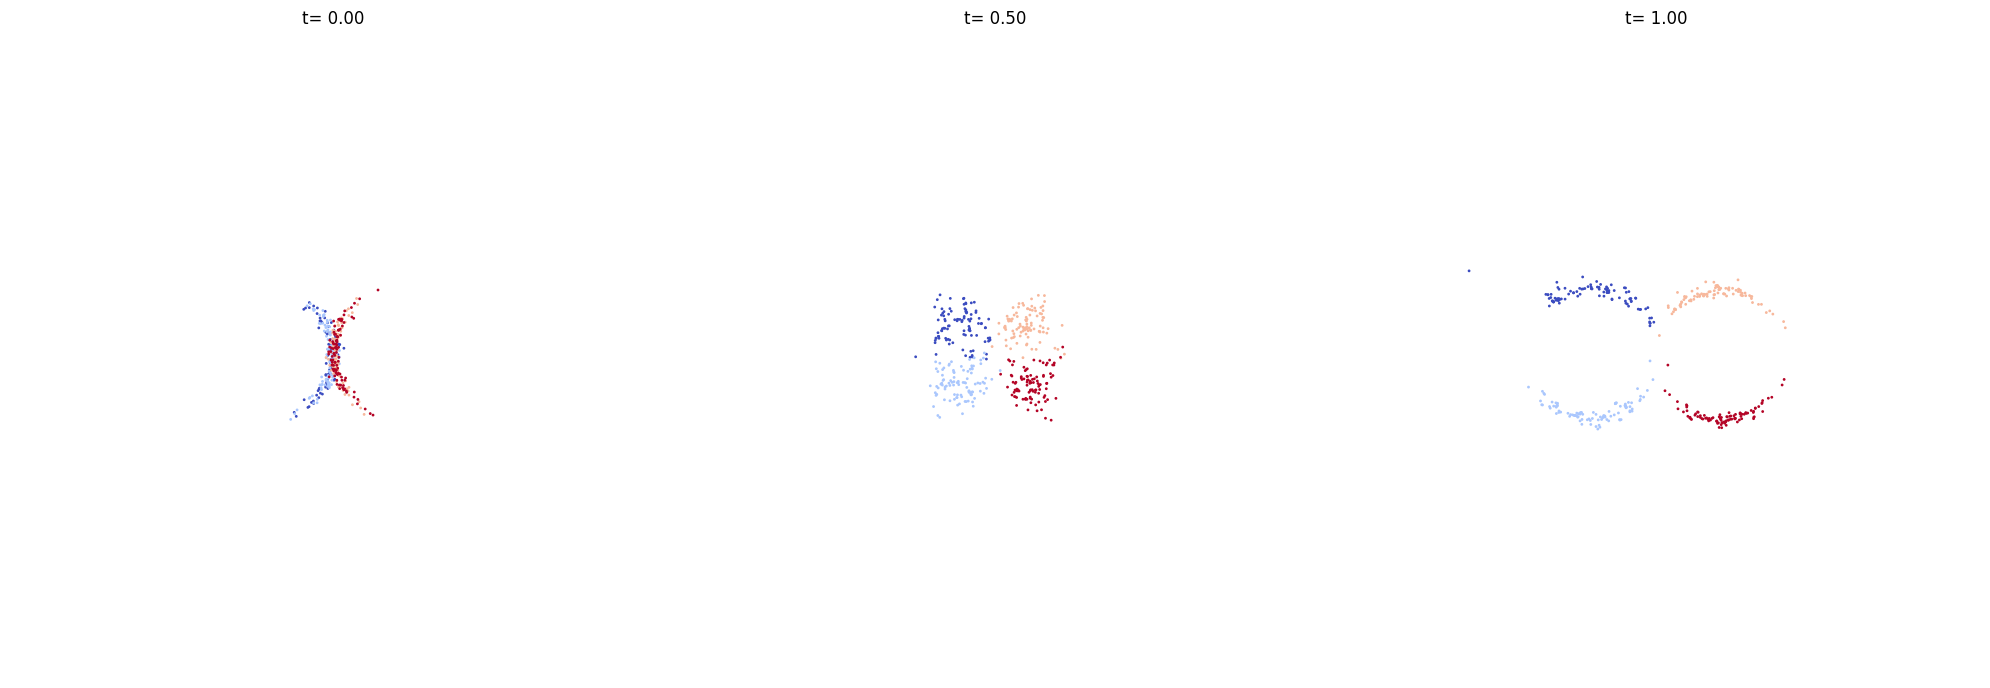

In [143]:
sol_0 = sol_0.cpu().numpy()
T = T.cpu()
cond = cond.cpu().numpy()

fig, axs = plt.subplots(1, 3,figsize=(20,20))

for i in range(3):
    axs[i].scatter(sol_0[i,:,0], sol_0[i,:,1], c=cond, cmap=cm.coolwarm, s=1)
    
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_xlim(-5, 5)
    axs[i].set_ylim(-5, 5)
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

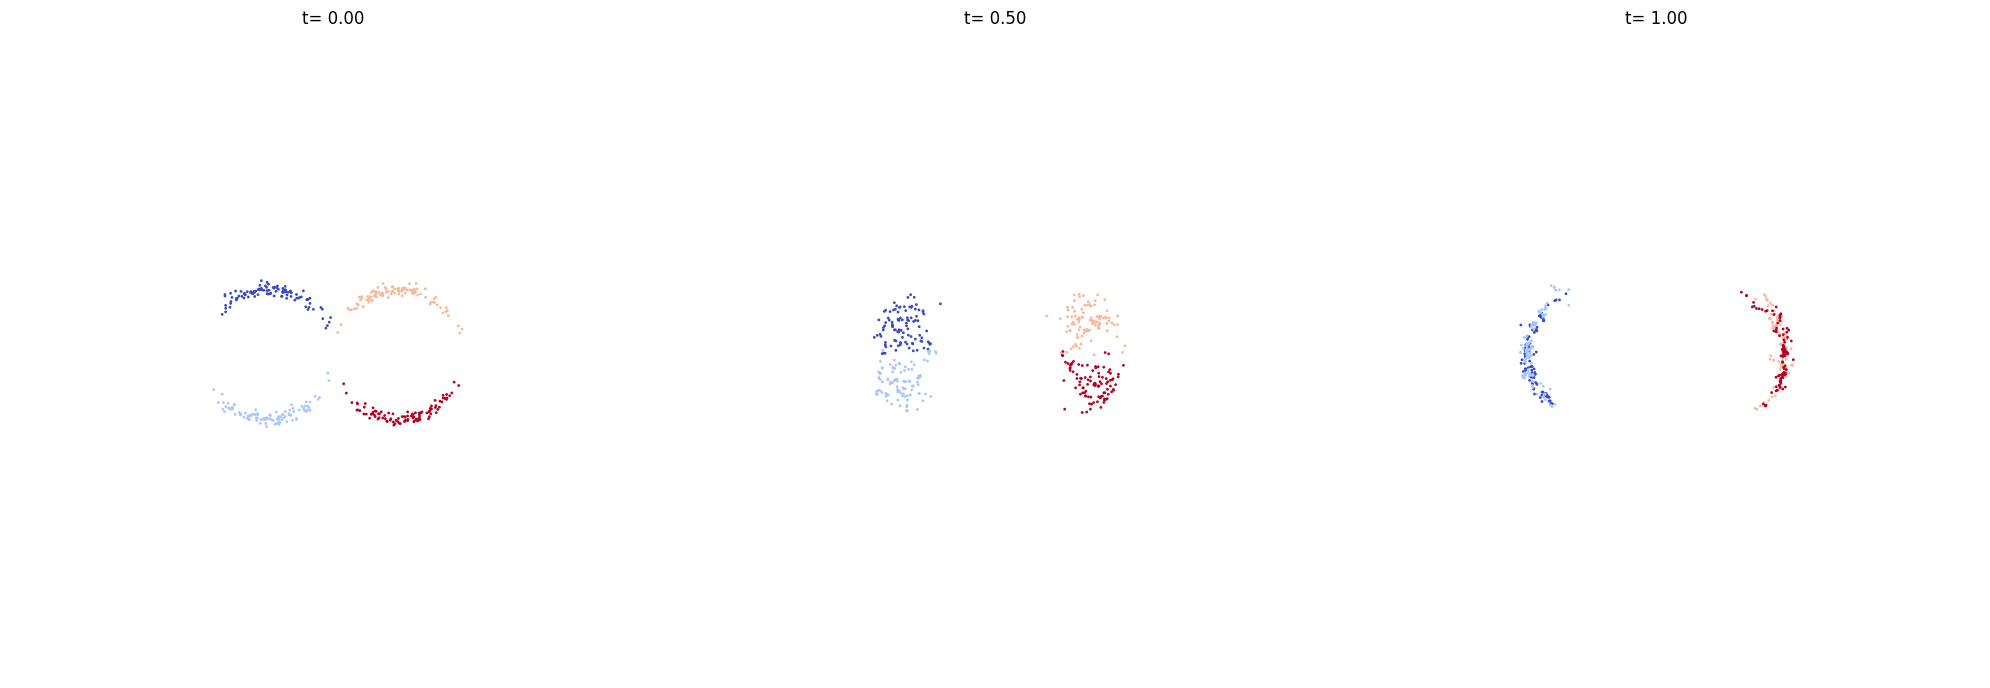

In [144]:
sol_1 = sol_1.cpu().numpy()
T = T.cpu()

fig, axs = plt.subplots(1, 3,figsize=(20,20))

for i in range(3):
    axs[i].scatter(sol_1[i,:,0], sol_1[i,:,1], c=cond, cmap=cm.coolwarm, s=1)
    
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_xlim(-5, 5)
    axs[i].set_ylim(-5, 5)
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

In [146]:
sol_0_midpoint_w_cond = np.concatenate([sol_0[1,:,:], cond[:, None]], axis=1)
sol_1_midpoint_w_cond = np.concatenate([sol_1[1,:,:], cond[:, None]], axis=1)

In [147]:
def log_likelihood_conditional_semicircle(
        data: torch.Tensor, # Shape (N, 3): [x, y, condition]
        time: float,
        radius: float = 1.0,
        angular_concentration: float = 5.0,
        radial_std_dev: float = 0.05 # Std dev for log(radius), 's' parameter for lognorm
    ) -> float:
    """
    Calculates the total log-likelihood of the given data under the semicircle model
    for a specific time and model parameters.

    Args:
        data (torch.Tensor): Input data of shape (N, 3), where columns are [x, y, condition].
                             Conditions should be integers 0, 1, 2, 3.
        time (float): Continuous time at which the data is assumed to be generated.
        radius (float): Radius of the semicircles.
        angular_concentration (float): Concentration parameter for the von Mises distribution.
        radial_std_dev (float): Standard deviation for the log of the radial distribution.

    Returns:
        float: The total log-likelihood of the dataset.
    """
    if data.ndim != 2 or data.shape[1] != 3:
        raise ValueError("Input data must have shape (N, 3)")

    data_np = data.cpu().numpy()
    x_coords = data_np[:, 0]
    y_coords = data_np[:, 1]
    conditions = data_np[:, 2].astype(int)

    total_log_likelihood = 0.0
    
    log_normal_mu_param = np.log(radius) # mu parameter for the underlying normal of lognorm

    for c_val in range(4):
        mask = (conditions == c_val)
        if not np.any(mask):
            continue

        current_x = x_coords[mask]
        current_y = y_coords[mask]

        # Determine target angle and center for the condition and time
        if c_val == 0:
            target_angle = time * np.pi
            center_x = -1.0
        elif c_val == 1:
            target_angle = -time * np.pi
            center_x = -1.0
        elif c_val == 2:
            target_angle = np.pi - time * np.pi
            center_x = 1.0
        else:  # c_val == 3
            target_angle = -np.pi + time * np.pi
            center_x = 1.0
        
        x_local = current_x - center_x
        y_local = current_y 

        epsilon = 1e-9 # To avoid log(0) or issues with r_polar=0
        r_polar = np.sqrt(x_local**2 + y_local**2)
        theta_polar = np.arctan2(y_local, x_local)

        log_pdf_angles = scipy_vonmises.logpdf(theta_polar, loc=target_angle, kappa=angular_concentration)
        valid_radii_mask = r_polar > epsilon
        log_pdf_radii = np.full_like(r_polar, -np.inf)

        if np.any(valid_radii_mask):
            log_pdf_radii[valid_radii_mask] = scipy_lognorm.logpdf(
                r_polar[valid_radii_mask],
                s=radial_std_dev,                # Shape parameter (sigma of underlying log)
                loc=0,                           # Shift parameter
                scale=np.exp(log_normal_mu_param) # Scale parameter (exp(mu of underlying log))
            )

        # Jacobian for polar to Cartesian transformation: pdf_cartesian = pdf_polar / r
        # So, log_pdf_cartesian = log_pdf_polar - log(r)
        log_jacobian_term = np.full_like(r_polar, -np.inf)
        if np.any(valid_radii_mask):
            log_jacobian_term[valid_radii_mask] = -np.log(r_polar[valid_radii_mask])

        # Sum log likelihoods for points in this condition (only for valid radii)
        current_log_likelihood = np.sum(
            log_pdf_angles[valid_radii_mask] + \
            log_pdf_radii[valid_radii_mask] + \
            log_jacobian_term[valid_radii_mask]
        )
        
        total_log_likelihood += current_log_likelihood
        
    return float(total_log_likelihood)

In [ ]:
circle_centers = {0: np.array([-1.0, 0.0]), 1: np.array([-1.0, 0.0]), 2: np.array([1.0, 0.0]), 3: np.array([1.0, 0.0])}
circle_radius = 1.0
per_condition_circle_dist = []

for cond_idx, true_cond_vec in enumerate(unique_true_conditions):
    true_cond_mask = np.all(true_conditions_all == true_cond_vec, axis=1)
    pred_cond_mask = np.all(predicted_conditions_all == true_cond_vec, axis=1)

    pred_samples_for_cond = predicted_spatial_overall[pred_cond_mask]

    if pred_samples_for_cond.shape[0] > 0:
        center = circle_centers[cond_idx]
        distances = np.abs(np.linalg.norm(pred_samples_for_cond - center, axis=1) - circle_radius)
        avg_distance = np.mean(distances)
        per_condition_circle_dist.append(avg_distance)
        metrics_log[f"time_{eval_time:.4f}_cond_{cond_idx}_circle_dist"] = float(avg_distance)

if per_condition_circle_dist:
    avg_circle_dist = np.mean(np.array(per_condition_circle_dist))
    metrics_log[f"time_{eval_time:.4f}_avg_circle_dist"] = float(avg_circle_dist)
    all_circle_distances.extend(per_condition_circle_dist)
    if verbose:
        print(f"Avg Circle Distance Across Conditions: {avg_circle_dist:.4e}")

In [161]:
circle_centers = {0: np.array([-1.0, 0.0]), 1: np.array([-1.0, 0.0]), 2: np.array([1.0, 0.0]), 3: np.array([1.0, 0.0])}
circle_radius = 1.0
per_condition_circle_dist = []

for cond_idx, cond_vec in enumerate([0,1,2,3]):
    all_midpoint_samples = np.vstack((sol_0_midpoint_w_cond, sol_1_midpoint_w_cond))
    #select samples from all_midpoint_samples that match the condition
    cond_mask = all_midpoint_samples[:, -1] == cond_vec
    cond_samples = all_midpoint_samples[cond_mask, :-1]
    center = circle_centers[cond_idx]
    distances = np.abs(np.linalg.norm(cond_samples - center, axis=1) - circle_radius)
    avg_distance = np.mean(distances)
    per_condition_circle_dist.append(avg_distance)

avg_circle_dist = np.mean(np.array(per_condition_circle_dist))
print(f"Avg Circle Distance Across Conditions: {avg_circle_dist}")

Avg Circle Distance Across Conditions: 0.3221959247820433


In [163]:
nll_0 = -log_likelihood_conditional_semicircle(torch.tensor(sol_0_midpoint_w_cond), time=0.25)/400
nll_1 = -log_likelihood_conditional_semicircle(torch.tensor(sol_1_midpoint_w_cond), time=0.75)/400

avg_nll = (nll_0 + nll_1) / 2
print(f"Average Negative Log-Likelihood: {avg_nll}")

Average Negative Log-Likelihood: 98.32533174374133


# CFM Semicircles results

In [167]:
cfm_nlls = []
cfm_cds = []

for i in range(5):
    print('ITERATION', i)
    lr = 0.001
    batch_size = 4096
    iterations = 20001
    print_every = 2000 
    hidden_dim = 512

    # velocity field model for time 0 to 0.5 init
    vf_0 = MLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=hidden_dim).to(device) 

    # instantiate an affine path object
    path = AffineProbPath(scheduler=CondOTScheduler())

    # init optimizer
    optim = torch.optim.Adam(vf_0.parameters(), lr=lr) 

    # train
    start_time = time.time()
    print('Training velocity field model for time 0 to 0.5')
    for i in range(iterations):
        optim.zero_grad() 

        # sample data (user's responsibility): in this case, (X_0,X_1) ~ pi(X_0,X_1) = N(X_0|0,I)q(X_1)
        data = semicircle_data()
        x_1 = data[1, :, :2] # sample data
        conds = data[1, :,2]
        #x_0 = torch.randn_like(x_1).to(device)
        x_0 = data[0,:,:2]

        # sample time (user's responsibility)
        t = torch.rand(x_1.shape[0]).to(device) 

        # sample probability path
        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

        # flow matching l2 loss
        loss = torch.pow(vf_0(path_sample.x_t,path_sample.t, conds) - path_sample.dx_t, 2).mean() 

        # optimizer step
        loss.backward() # backward
        optim.step() # update
        
        # log loss
        if (i+1) % print_every == 0:
            elapsed = time.time() - start_time
            print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
                .format(i+1, elapsed*1000/print_every, loss.item())) 
            start_time = time.time()

    # velocity field model for time 0.5 to 1.0 init
    vf_1 = MLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=hidden_dim).to(device) 

    # instantiate an affine path object
    path = AffineProbPath(scheduler=CondOTScheduler())

    # init optimizer
    optim = torch.optim.Adam(vf_1.parameters(), lr=lr) 

    # train
    start_time = time.time()
    print('Training velocity field model for time 0.5 to 1.0')
    for i in range(iterations):
        optim.zero_grad() 

        # sample data (user's responsibility): in this case, (X_0,X_1) ~ pi(X_0,X_1) = N(X_0|0,I)q(X_1)
        data = semicircle_data()
        x_1 = data[2, :, :2] # sample data
        conds = data[2, :,2]
        #x_0 = torch.randn_like(x_1).to(device)
        x_0 = data[1,:,:2]

        # sample time (user's responsibility)
        t = torch.rand(x_1.shape[0]).to(device) 

        # sample probability path
        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

        # flow matching l2 loss
        loss = torch.pow(vf_1(path_sample.x_t,path_sample.t, conds) - path_sample.dx_t, 2).mean() 

        # optimizer step
        loss.backward() # backward
        optim.step() # update
        
        # log loss
        if (i+1) % print_every == 0:
            elapsed = time.time() - start_time
            print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
                .format(i+1, elapsed*1000/print_every, loss.item())) 
            start_time = time.time()

    class WrappedModel(ModelWrapper):
        def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
            return self.model(x, t, cond)

    wrapped_vf_0 = WrappedModel(vf_0)
    wrapped_vf_1 = WrappedModel(vf_1)

    # step size for ode solver
    step_size = 0.05

    norm = cm.colors.Normalize(vmax=50, vmin=0)

    batch_size = 50000  # batch size
    eps_time = 1e-2
    T = torch.linspace(0,1,3)  # sample times
    T = T.to(device=device)

    #x_init = torch.randn((batch_size, 2), dtype=torch.float32, device=device)
    x_init = data[0,:,:2]
    #cond = torch.randint(0, 4, (batch_size, 1), device=device).float()
    cond = data[0,:,2]

    x_1_init = data[1,:,:2]  # initial condition for the second time step

    solver_0 = ODESolver(velocity_model=wrapped_vf_0)  # create an ODESolver class
    sol_0 = solver_0.sample(time_grid=T, x_init=x_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True)  # sample from the model

    solver_1 = ODESolver(velocity_model=wrapped_vf_1) 
    sol_1 = solver_1.sample(time_grid=T, x_init=x_1_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True)  # sample from the model

    sol_0 = sol_0.cpu().numpy()
    sol_1 = sol_1.cpu().numpy()
    cond = cond.cpu().numpy()
    T = T.cpu()

    sol_0_midpoint_w_cond = np.concatenate([sol_0[1,:,:], cond[:, None]], axis=1)
    sol_1_midpoint_w_cond = np.concatenate([sol_1[1,:,:], cond[:, None]], axis=1)



    nll_0 = -log_likelihood_conditional_semicircle(torch.tensor(sol_0_midpoint_w_cond), time=0.25)/400
    nll_1 = -log_likelihood_conditional_semicircle(torch.tensor(sol_1_midpoint_w_cond), time=0.75)/400

    avg_nll = (nll_0 + nll_1) / 2
    print(f"Average Negative Log-Likelihood: {avg_nll}")
    cfm_nlls.append(avg_nll)


    circle_centers = {0: np.array([-1.0, 0.0]), 1: np.array([-1.0, 0.0]), 2: np.array([1.0, 0.0]), 3: np.array([1.0, 0.0])}
    circle_radius = 1.0
    per_condition_circle_dist = []

    for cond_idx, cond_vec in enumerate([0,1,2,3]):
        all_midpoint_samples = np.vstack((sol_0_midpoint_w_cond, sol_1_midpoint_w_cond))
        #select samples from all_midpoint_samples that match the condition
        cond_mask = all_midpoint_samples[:, -1] == cond_vec
        cond_samples = all_midpoint_samples[cond_mask, :-1]
        center = circle_centers[cond_idx]
        distances = np.abs(np.linalg.norm(cond_samples - center, axis=1) - circle_radius)
        avg_distance = np.mean(distances)
        per_condition_circle_dist.append(avg_distance)

    avg_circle_dist = np.mean(np.array(per_condition_circle_dist))
    
    print(f"Avg Circle Distance Across Conditions: {avg_circle_dist}")
    cfm_cds.append(avg_circle_dist)
    

    

ITERATION 0
Training velocity field model for time 0 to 0.5


| iter   2000 |  2.29 ms/step | loss    0.042 
| iter   4000 |  2.19 ms/step | loss    0.039 
| iter   6000 |  2.21 ms/step | loss    0.031 
| iter   8000 |  2.16 ms/step | loss    0.032 
| iter  10000 |  2.33 ms/step | loss    0.031 
| iter  12000 |  2.34 ms/step | loss    0.021 
| iter  14000 |  2.34 ms/step | loss    0.021 
| iter  16000 |  2.32 ms/step | loss    0.017 
| iter  18000 |  2.20 ms/step | loss    0.015 
| iter  20000 |  2.16 ms/step | loss    0.012 
Training velocity field model for time 0.5 to 1.0
| iter   2000 |  2.39 ms/step | loss    0.046 
| iter   4000 |  2.45 ms/step | loss    0.040 
| iter   6000 |  2.34 ms/step | loss    0.035 
| iter   8000 |  2.29 ms/step | loss    0.034 
| iter  10000 |  2.33 ms/step | loss    0.031 
| iter  12000 |  2.38 ms/step | loss    0.030 
| iter  14000 |  2.37 ms/step | loss    0.026 
| iter  16000 |  2.30 ms/step | loss    0.019 
| iter  18000 |  2.40 ms/step | loss    0.020 
| iter  20000 |  2.44 ms/step | loss    0.013 
Average Ne

In [168]:
cfm_cds

[0.33953084520205123,
 0.3214014870939345,
 0.33182925488823745,
 0.32778488611937573,
 0.3142215719881015]

In [169]:
cfm_nlls

[97.5503541242816,
 99.47670691209676,
 99.9703188602732,
 95.55106689594058,
 84.24794472582178]

In [170]:
def print_results(results, name):
    mean = np.mean(results)
    std = np.std(results)
    ci = 1.96 * std / np.sqrt(len(results))
    print(f"{name}: {mean:.3f} ± {ci:.3f}")

In [173]:
print_results(cfm_nlls, "CFM NLL")
print_results(cfm_cds, "CFM Circle Distances")

CFM NLL: 95.359 ± 5.058
CFM Circle Distances: 0.327 ± 0.008


# CFM Reward Weighting

In [5]:
def rl_data_gen():
    """
    Loads the rl reward weighting dataset.
    """

    data = torch.load("../NLOT/data/reward_weighting_data_0_10.pt")
    data = data.to(device)
    return data

In [6]:
rl_data = rl_data_gen()
rl_data = rl_data[:,:1000]

In [11]:
# training arguments
lr = 0.001
batch_size = 4096
iterations = 20001
print_every = 2000 
hidden_dim = 512

vf_0 = MLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=hidden_dim).to(device) 
path = AffineProbPath(scheduler=CondOTScheduler())
optim = torch.optim.Adam(vf_0.parameters(), lr=lr) 
start_time = time.time()
print('Training velocity field model for time 0 to 0.5')
for i in range(iterations):
    optim.zero_grad() 

    x_1 = rl_data[5, :, :2] 
    x_0 = rl_data[0, :, :2]
    conds = rl_data[0, :, 2:]
    t = torch.rand(x_1.shape[0]).to(device) 
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
    loss = torch.pow(vf_0(path_sample.x_t,path_sample.t, conds) - path_sample.dx_t, 2).mean() 
    loss.backward() 
    optim.step()
    
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
              .format(i+1, elapsed*1000/print_every, loss.item())) 
        start_time = time.time()



vf_1 = MLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=hidden_dim).to(device) 
path = AffineProbPath(scheduler=CondOTScheduler())
optim = torch.optim.Adam(vf_1.parameters(), lr=lr) 
start_time = time.time()
print('Training velocity field model for time 0.5 to 1')
for i in range(iterations):
    optim.zero_grad() 

    x_1 = rl_data[10, :, :2] 
    x_0 = rl_data[5, :, :2]
    conds = rl_data[5, :, 2:]
    t = torch.rand(x_1.shape[0]).to(device) 
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
    loss = torch.pow(vf_1(path_sample.x_t,path_sample.t, conds) - path_sample.dx_t, 2).mean() 
    loss.backward() 
    optim.step()
    
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
              .format(i+1, elapsed*1000/print_every, loss.item())) 
        start_time = time.time()

Training velocity field model for time 0 to 0.5


| iter   2000 |  1.26 ms/step | loss    0.360 
| iter   4000 |  1.17 ms/step | loss    0.243 
| iter   6000 |  1.20 ms/step | loss    0.099 
| iter   8000 |  1.28 ms/step | loss    0.053 
| iter  10000 |  1.28 ms/step | loss    0.030 
| iter  12000 |  1.28 ms/step | loss    0.038 
| iter  14000 |  1.28 ms/step | loss    0.028 
| iter  16000 |  1.28 ms/step | loss    0.026 
| iter  18000 |  1.28 ms/step | loss    0.018 
| iter  20000 |  1.28 ms/step | loss    0.018 
Training velocity field model for time 0.5 to 1
| iter   2000 |  1.17 ms/step | loss    0.392 
| iter   4000 |  1.17 ms/step | loss    0.255 
| iter   6000 |  1.17 ms/step | loss    0.089 
| iter   8000 |  1.17 ms/step | loss    0.055 
| iter  10000 |  1.17 ms/step | loss    0.025 
| iter  12000 |  1.17 ms/step | loss    0.020 
| iter  14000 |  1.17 ms/step | loss    0.031 
| iter  16000 |  1.17 ms/step | loss    0.016 
| iter  18000 |  1.17 ms/step | loss    0.016 
| iter  20000 |  1.17 ms/step | loss    0.014 


In [12]:
class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
        return self.model(x, t, cond)

wrapped_vf_0 = WrappedModel(vf_0)
wrapped_vf_1 = WrappedModel(vf_1)

In [23]:
#save wrapped models

torch.save(wrapped_vf_0.state_dict(), 'wrapped_vf_0_rl.pt')
torch.save(wrapped_vf_1.state_dict(), 'wrapped_vf_1_rl.pt')

In [ ]:
#load wrapped models

state_dict_0 = torch.load('wrapped_vf_0_rl.pt')
state_dict_1 = torch.load('wrapped_vf_1_rl.pt')

wrapped_vf_0.load_state_dict(state_dict_0)

In [43]:
step_size = 0.05
T = torch.linspace(0,1,6)
T = T.to(device=device)
x_init = rl_data[0,:,:2]
cond = rl_data[0,:,2:]
solver_0 = ODESolver(velocity_model=wrapped_vf_0) 
sol_0 = solver_0.sample(time_grid=torch.tensor([0.0, 0.5]), x_init=x_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True) 

solver_1 = ODESolver(velocity_model=wrapped_vf_1)
x_1_init = rl_data[5,:,:2]  
sol_1 = solver_1.sample(time_grid=T, x_init=x_1_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True)

In [44]:
rl_data[0,:,:2]

tensor([[0.0000, 2.9636],
        [0.0000, 2.0878],
        [0.0000, 1.9326],
        ...,
        [3.6152, 2.4422],
        [3.6362, 1.8309],
        [3.6808, 2.7200]], device='cuda:0')

In [45]:
sol_0[1]

tensor([[2.8853, 2.0871],
        [3.1647, 1.3941],
        [3.2921, 1.0091],
        ...,
        [2.8475, 2.5805],
        [2.6434, 1.5300],
        [2.3784, 3.0519]], device='cuda:0')

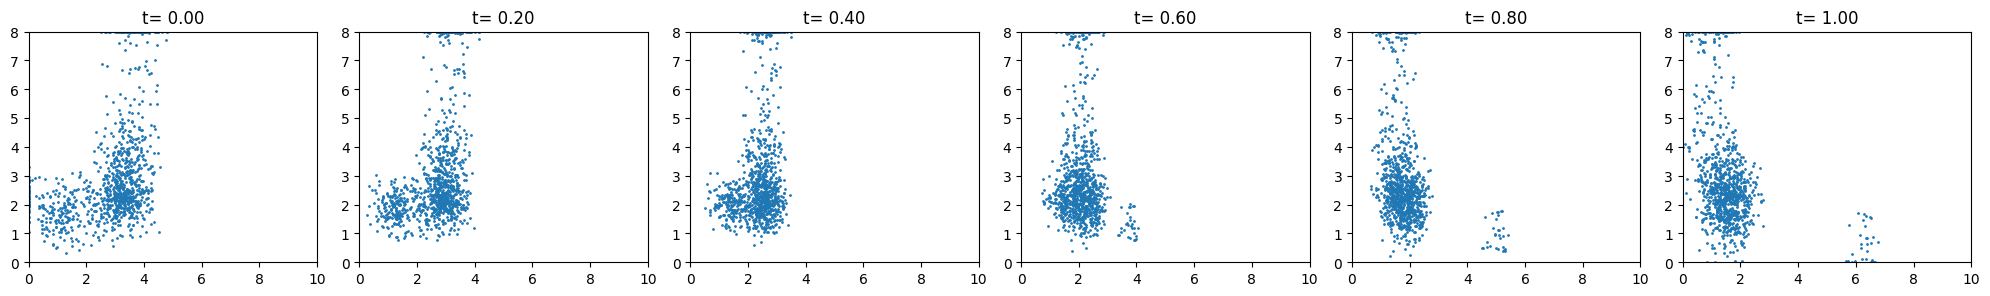

In [14]:
sol_0 = sol_0.cpu().numpy()
T = T.cpu()
cond = cond.cpu().numpy()
fig, axs = plt.subplots(1, 6,figsize=(20,20))

for i in range(6):
    #clip the values to [0,10] and [0,8]
    sol_0[i,:,0] = np.clip(sol_0[i,:,0], 0, 10)
    sol_0[i,:,1] = np.clip(sol_0[i,:,1], 0, 8)
    axs[i].scatter(sol_0[i,:,0], sol_0[i,:,1], s=1)
    axs[i].set_aspect('equal')
    axs[i].set_xlim(0, 10)
    axs[i].set_ylim(0, 8)
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

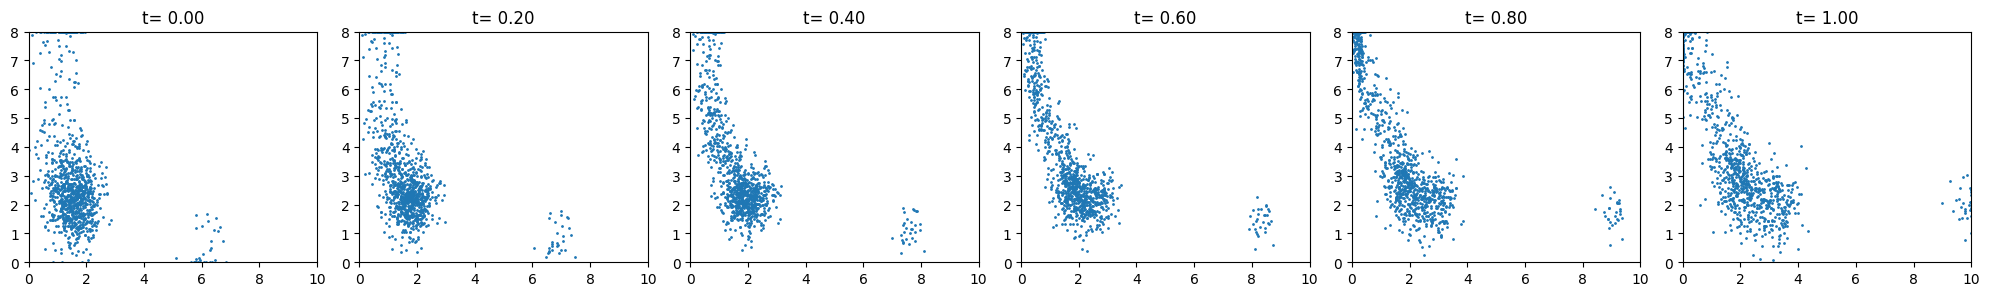

In [15]:
sol_1 = sol_1.cpu().numpy()
fig, axs = plt.subplots(1, 6,figsize=(20,20))

for i in range(6):
    #clip the values to [0,10] and [0,8]
    sol_1[i,:,0] = np.clip(sol_1[i,:,0], 0, 10)
    sol_1[i,:,1] = np.clip(sol_1[i,:,1], 0, 8)
    axs[i].scatter(sol_1[i,:,0], sol_1[i,:,1], s=1)
    axs[i].set_aspect('equal')
    axs[i].set_xlim(0, 10)
    axs[i].set_ylim(0, 8)
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

(0.0, 8.0)

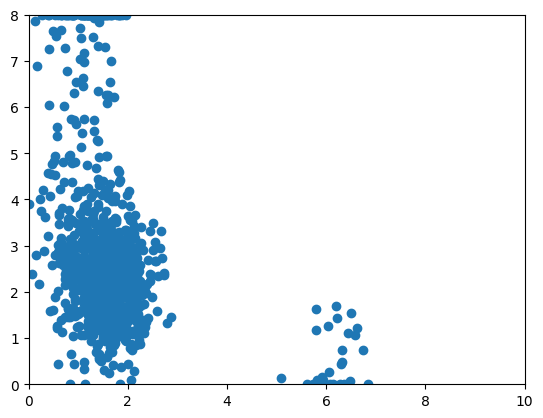

In [17]:
plt.scatter(rl_data[5, :, 0].cpu(), rl_data[5, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

(0.0, 8.0)

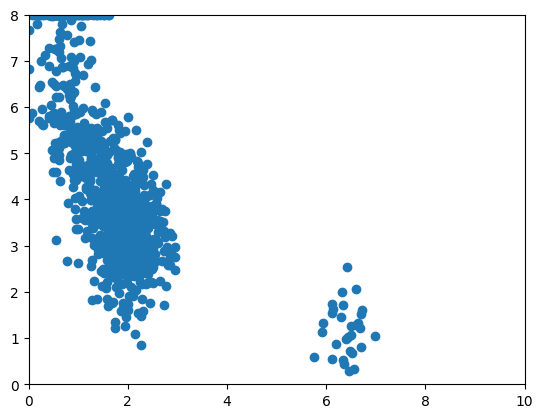

In [18]:
plt.scatter(rl_data[6, :, 0].cpu(), rl_data[6, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

(0.0, 8.0)

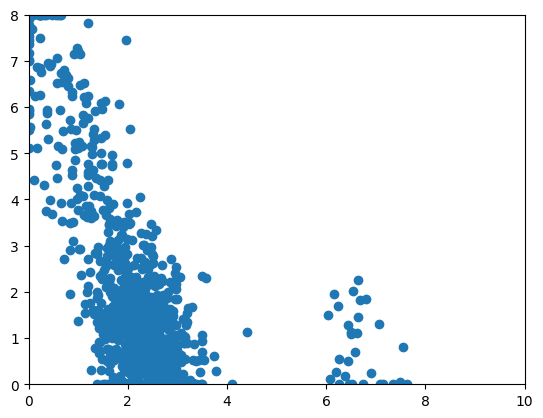

In [19]:
plt.scatter(rl_data[7, :, 0].cpu(), rl_data[7, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

(0.0, 8.0)

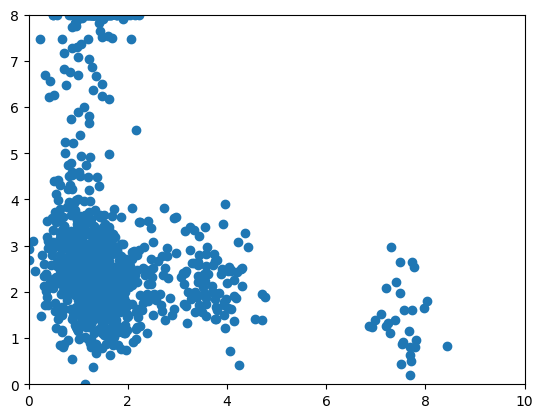

In [20]:
plt.scatter(rl_data[8, :, 0].cpu(), rl_data[8, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

(0.0, 8.0)

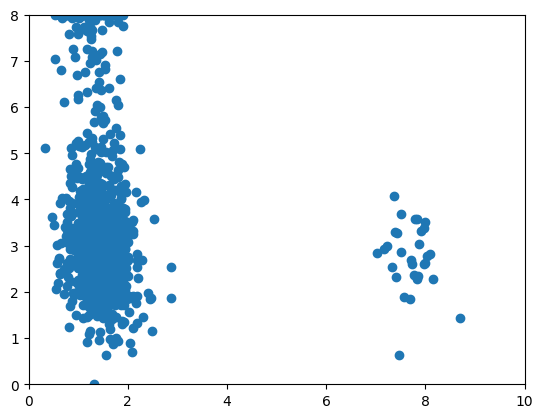

In [21]:
plt.scatter(rl_data[9, :, 0].cpu(), rl_data[9, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

(0.0, 8.0)

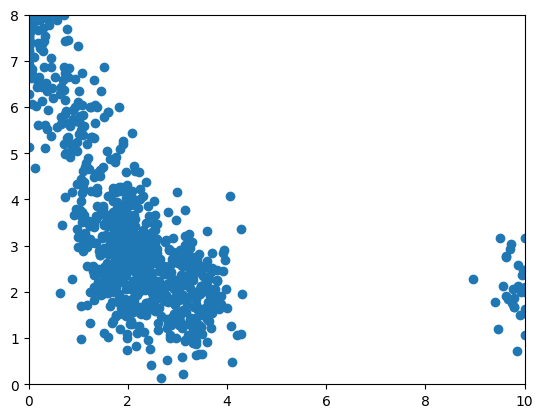

In [22]:
plt.scatter(rl_data[10, :, 0].cpu(), rl_data[10, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

# RL Eval Testing